In [1]:
# This cell imports libraries and defines project/data paths.

from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style, apply openpyxl's default"
)

cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"
TS_ROUTE_DIR = DATA_DIR / "traffic_stats" / "routes"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TS_ROUTE_DIR =", TS_ROUTE_DIR)
print("PROCESSED_DIR =", PROCESSED_DIR)

PROJECT_ROOT = D:\JupyterProjects\tomtom_move
TS_ROUTE_DIR = D:\JupyterProjects\tomtom_move\data\traffic_stats\routes
PROCESSED_DIR = D:\JupyterProjects\tomtom_move\data\processed


In [2]:
# This cell locates the TomTom workbook and shows all sheet names.

workbook_path = TS_ROUTE_DIR / "jobs_9031079_results_Worcester_test.xlsx"

if not workbook_path.exists():
    candidates = sorted(TS_ROUTE_DIR.glob("*.xlsx"))
    if not candidates:
        raise FileNotFoundError("No .xlsx file found in data/traffic_stats/routes/")
    workbook_path = candidates[0]

print("Using workbook:", workbook_path.name)

xls = pd.ExcelFile(workbook_path, engine="openpyxl")
sheet_names = xls.sheet_names

print("\nSheets in workbook:")
for s in sheet_names:
    print("-", s)

Using workbook: jobs_9031079_results_Worcester_test.xlsx

Sheets in workbook:
- Worcester_test
- Route1-Speeds(harmonic avg)
- Route1-Speeds(arithmetic avg)
- Route1-Speeds(median)
- Route1-Sample size
- Route1-Normalized sample size
- Route1-PercentileSpeeds
- Route1-PercentileTravelTimes
- Route1-CumulativeTravelTimes
- Route1-RelativeStdDeviation
- Route1-TravelTimeRatio
- Route1-PercentilesEachSegment
- Route2-Speeds(harmonic avg)
- Route2-Speeds(arithmetic avg)
- Route2-Speeds(median)
- Route2-Sample size
- Route2-Normalized sample size
- Route2-PercentileSpeeds
- Route2-PercentileTravelTimes
- Route2-CumulativeTravelTimes
- Route2-RelativeStdDeviation
- Route2-TravelTimeRatio
- Route2-PercentilesEachSegment
- Route3-Speeds(harmonic avg)
- Route3-Speeds(arithmetic avg)
- Route3-Speeds(median)
- Route3-Sample size
- Route3-Normalized sample size
- Route3-PercentileSpeeds
- Route3-PercentileTravelTimes
- Route3-CumulativeTravelTimes
- Route3-RelativeStdDeviation
- Route3-TravelTimeR

In [3]:
# This cell defines helper functions for cleaning column names, normalizing labels, and building plot labels.

def clean_col(c):
    c = str(c).strip()
    c = c.replace("\n", " ")
    c = re.sub(r"\s+", " ", c)
    return c

def normalize_time_set_label(s):
    s = str(s).strip()

    # Ratio columns look like:
    # "PM_Peak: 16:00-19:00 / AM_Peak: 7:00-9:00"
    # We only keep the left side.
    if " / " in s:
        s = s.split(" / ")[0].strip()

    mapping = {
        "AM_Peak: 7:00-9:00": "AM Peak",
        "Midday: 11:00-13:00": "Midday",
        "PM_Peak: 16:00-19:00": "PM Peak",
        "Weekend_noon: 11:00-14:00": "Weekend Noon",
    }
    return mapping.get(s, s)

def normalize_route_name(s):
    mapping = {
        "main_street_corridoor": "Main Street Corridor",
        "park_avenue_corridor": "Park Avenue Corridor",
        "chandler_street_corridor": "Chandler Street Corridor",
        "downtown_to_i290_connector": "Downtown to I-290 Connector",
        "downtown_cross_town_route": "Downtown Cross-Town Route"
    }
    return mapping.get(str(s), str(s))

def make_segment_label(df):
    distance_text = np.where(
        df["distance_m"].notna(),
        df["distance_m"].round(0).astype(int).astype(str) + "m",
        "ID " + df["segment_id"].astype(str).str[-6:]
    )
    return (
        df["street_name"].fillna("Segment").astype(str)
        + " | "
        + distance_text
    )

In [4]:
# This cell reads the route-level summary sheet from the workbook.

summary = pd.read_excel(
    workbook_path,
    sheet_name="Worcester_test",
    engine="openpyxl",
    header=19
)

summary = summary.dropna(how="all").copy()

print("Summary shape:", summary.shape)
print("\nOriginal columns:")
print(summary.columns.tolist())

summary.head()

Summary shape: (20, 37)

Original columns:
['Route Id', 'Route', 'Date Range', 'Time Set', 'Full Traversal', 'Probe Source', 'Covered Route Length [meters]', 'Sample size [avg per segment]', 'Average Travel Time [hh:mm:ss]', 'Median Travel Time [hh:mm:ss]', 'Harmonic Average Speed [kph]', '15th percentile Speed [kph]', '85th percentile Speed [kph]', 'Average Travel Time ratios', 'Planning Time Index', '5th percentile travel time [hh:mm:ss]', '10th percentile travel time [hh:mm:ss]', '15th percentile travel time [hh:mm:ss]', '20th percentile travel time [hh:mm:ss]', '25th percentile travel time [hh:mm:ss]', '30th percentile travel time [hh:mm:ss]', '35th percentile travel time [hh:mm:ss]', '40th percentile travel time [hh:mm:ss]', '45th percentile travel time [hh:mm:ss]', '50th percentile travel time [hh:mm:ss]', '55th percentile travel time [hh:mm:ss]', '60th percentile travel time [hh:mm:ss]', '65th percentile travel time [hh:mm:ss]', '70th percentile travel time [hh:mm:ss]', '75th pe

,Route Id,Route,Date Range,Time Set,Full Traversal,Probe Source,Covered Route Length [meters],Sample size [avg per segment],Average Travel Time [hh:mm:ss],Median Travel Time [hh:mm:ss],...,65th percentile travel time [hh:mm:ss],70th percentile travel time [hh:mm:ss],75th percentile travel time [hh:mm:ss],80th percentile travel time [hh:mm:ss],85th percentile travel time [hh:mm:ss],90th percentile travel time [hh:mm:ss],95th percentile travel time [hh:mm:ss],Total Route Length [meters],Map Versions,"Standard Deviation (of travel time, only full traversals) [hh:mm:ss]"
0,1,main_street_corridoor,selected_month,AM_Peak: 7:00-9:00,False,ALL,3982.20,2450.02,00:10:37,00:07:20,...,00:09:04,00:09:59,00:11:08,00:12:38,00:14:49,00:18:21,00:25:36,3982.20,CanadaAndUSANorth_nam2023.12.000-22.292-1 DSEG...,NaN
1,1,main_street_corridoor,selected_month,Midday: 11:00-13:00,False,ALL,3982.20,3131.72,00:13:05,00:08:55,...,00:11:21,00:12:35,00:14:10,00:16:13,00:19:01,00:23:28,00:32:00,3982.20,CanadaAndUSANorth_nam2023.12.000-22.292-1 DSEG...,NaN
2,1,main_street_corridoor,selected_month,PM_Peak: 16:00-19:00,False,ALL,3982.20,5934.22,00:13:36,00:09:13,...,00:11:59,00:13:22,00:15:13,00:17:32,00:20:53,00:25:35,00:34:41,3982.20,CanadaAndUSANorth_nam2023.12.000-22.292-1 DSEG...,NaN
3,1,main_street_corridoor,selected_month,Weekend_noon: 11:00-14:00,False,ALL,3982.20,1367.19,00:12:18,00:08:39,...,00:10:47,00:11:54,00:13:15,00:15:11,00:17:45,00:21:39,00:29:36,3982.20,CanadaAndUSANorth_nam2023.12.000-22.292-1 DSEG...,NaN
4,2,park_avenue_corridor,selected_month,AM_Peak: 7:00-9:00,False,ALL,4752.46,7948.87,00:10:36,00:06:53,...,00:08:28,00:09:29,00:10:54,00:12:51,00:15:49,00:20:21,00:29:10,4752.46,CanadaAndUSANorth_nam2023.12.000-22.292-1 DSEG...,NaN


In [5]:
# This cell cleans and renames the summary columns to short analysis-friendly names.

summary.columns = [clean_col(c) for c in summary.columns]

summary = summary.rename(columns={
    "Route Id": "route_id",
    "Route": "route_name",
    "Date Range": "date_range",
    "Time Set": "time_set",
    "Covered Route Length [meters]": "covered_length_m",
    "Sample size [avg per segment]": "sample_size_avg",
    "Average Travel Time [hh:mm:ss]": "avg_travel_time",
    "Median Travel Time [hh:mm:ss]": "median_travel_time",
    "Harmonic Average Speed [kph]": "harmonic_avg_speed_kph",
    "15th percentile Speed [kph]": "p15_speed_kph",
    "85th percentile Speed [kph]": "p85_speed_kph",
    "Average Travel Time ratios": "avg_travel_time_ratio",
    "Planning Time Index": "planning_time_index",
    "Total Route Length [meters]": "total_length_m"
})

summary = summary[[
    "route_id", "route_name", "date_range", "time_set",
    "covered_length_m", "sample_size_avg",
    "avg_travel_time", "median_travel_time",
    "harmonic_avg_speed_kph",
    "p15_speed_kph", "p85_speed_kph",
    "avg_travel_time_ratio", "planning_time_index",
    "total_length_m"
]].copy()

summary.head()

,route_id,route_name,date_range,time_set,covered_length_m,sample_size_avg,avg_travel_time,median_travel_time,harmonic_avg_speed_kph,p15_speed_kph,p85_speed_kph,avg_travel_time_ratio,planning_time_index,total_length_m
0,1,main_street_corridoor,selected_month,AM_Peak: 7:00-9:00,3982.20,2450.02,00:10:37,00:07:20,22.49,16.13,44.87,1.00,2.41,3982.20
1,1,main_street_corridoor,selected_month,Midday: 11:00-13:00,3982.20,3131.72,00:13:05,00:08:55,18.27,12.57,38.71,1.23,3.01,3982.20
2,1,main_street_corridoor,selected_month,PM_Peak: 16:00-19:00,3982.20,5934.22,00:13:36,00:09:13,17.56,11.44,38.81,1.28,3.26,3982.20
3,1,main_street_corridoor,selected_month,Weekend_noon: 11:00-14:00,3982.20,1367.19,00:12:18,00:08:39,19.44,13.46,39.75,1.16,2.79,3982.20
4,2,park_avenue_corridor,selected_month,AM_Peak: 7:00-9:00,4752.46,7948.87,00:10:36,00:06:53,26.91,18.02,55.61,1.00,2.75,4752.46


In [6]:
# This cell converts travel time to minutes and standardizes route and time-set names.

summary["avg_travel_time_min"] = pd.to_timedelta(summary["avg_travel_time"]).dt.total_seconds() / 60
summary["median_travel_time_min"] = pd.to_timedelta(summary["median_travel_time"]).dt.total_seconds() / 60

summary["route_name"] = summary["route_name"].apply(normalize_route_name)
summary["time_set"] = summary["time_set"].apply(normalize_time_set_label)

summary = summary.sort_values(["route_id", "time_set"]).reset_index(drop=True)

print(summary[["route_id", "route_name", "time_set"]].drop_duplicates())
summary.head()

    route_id                   route_name      time_set
0          1         Main Street Corridor       AM Peak
1          1         Main Street Corridor        Midday
2          1         Main Street Corridor       PM Peak
3          1         Main Street Corridor  Weekend Noon
4          2         Park Avenue Corridor       AM Peak
5          2         Park Avenue Corridor        Midday
6          2         Park Avenue Corridor       PM Peak
7          2         Park Avenue Corridor  Weekend Noon
8          3     Chandler Street Corridor       AM Peak
9          3     Chandler Street Corridor        Midday
10         3     Chandler Street Corridor       PM Peak
11         3     Chandler Street Corridor  Weekend Noon
12         4  Downtown to I-290 Connector       AM Peak
13         4  Downtown to I-290 Connector        Midday
14         4  Downtown to I-290 Connector       PM Peak
15         4  Downtown to I-290 Connector  Weekend Noon
16         5    Downtown Cross-Town Route       

,route_id,route_name,date_range,time_set,covered_length_m,sample_size_avg,avg_travel_time,median_travel_time,harmonic_avg_speed_kph,p15_speed_kph,p85_speed_kph,avg_travel_time_ratio,planning_time_index,total_length_m,avg_travel_time_min,median_travel_time_min
0,1,Main Street Corridor,selected_month,AM Peak,3982.20,2450.02,00:10:37,00:07:20,22.49,16.13,44.87,1.00,2.41,3982.20,10.616667,7.333333
1,1,Main Street Corridor,selected_month,Midday,3982.20,3131.72,00:13:05,00:08:55,18.27,12.57,38.71,1.23,3.01,3982.20,13.083333,8.916667
2,1,Main Street Corridor,selected_month,PM Peak,3982.20,5934.22,00:13:36,00:09:13,17.56,11.44,38.81,1.28,3.26,3982.20,13.600000,9.216667
3,1,Main Street Corridor,selected_month,Weekend Noon,3982.20,1367.19,00:12:18,00:08:39,19.44,13.46,39.75,1.16,2.79,3982.20,12.300000,8.650000
4,2,Park Avenue Corridor,selected_month,AM Peak,4752.46,7948.87,00:10:36,00:06:53,26.91,18.02,55.61,1.00,2.75,4752.46,10.600000,6.883333


In [7]:
# This cell saves the cleaned route-level summary table.

summary_path = PROCESSED_DIR / "route_summary_aug2024_clean.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: D:\JupyterProjects\tomtom_move\data\processed\route_summary_aug2024_clean.csv


In [8]:
# This cell builds an overall route comparison table by averaging across the four time sets.

route_overall = summary.groupby("route_name").agg(
    avg_travel_time_min=("avg_travel_time_min", "mean"),
    median_travel_time_min=("median_travel_time_min", "mean"),
    avg_speed_kph=("harmonic_avg_speed_kph", "mean"),
    avg_sample_size=("sample_size_avg", "mean"),
    avg_ratio=("avg_travel_time_ratio", "mean"),
    avg_planning_time_index=("planning_time_index", "mean")
).reset_index()

route_overall = route_overall.sort_values("avg_travel_time_min", ascending=False)

route_overall

,route_name,avg_travel_time_min,median_travel_time_min,avg_speed_kph,avg_sample_size,avg_ratio,avg_planning_time_index
3,Main Street Corridor,12.400000,8.529167,19.4400,3220.7875,1.1675,2.8675
4,Park Avenue Corridor,11.454167,7.283333,24.9450,7575.6900,1.0800,2.9850
0,Chandler Street Corridor,9.616667,6.762500,29.6475,5149.5300,1.1050,2.5300
1,Downtown Cross-Town Route,9.587500,6.279167,23.3325,6736.3025,0.9925,2.6300
2,Downtown to I-290 Connector,3.762500,2.058333,17.0425,5188.9475,1.0275,3.0875


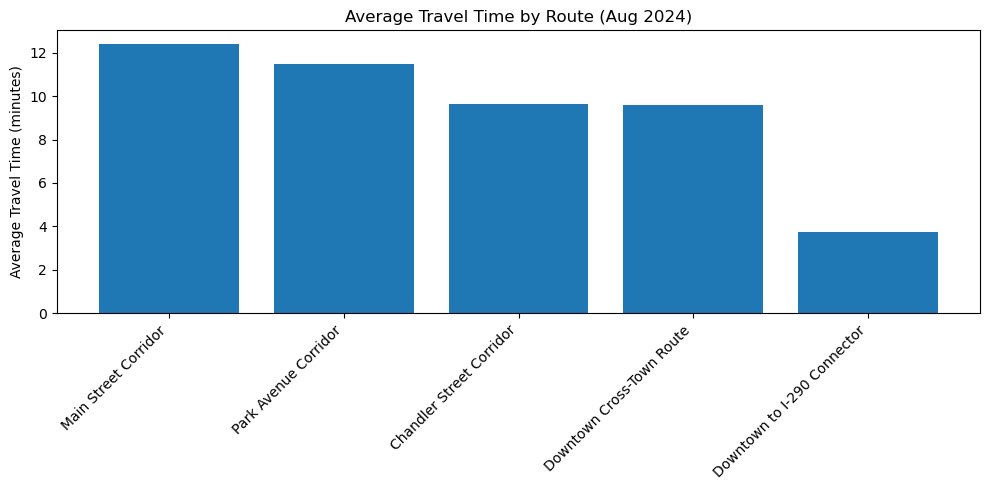

In [9]:
# This cell plots average travel time by route.

plot_df = route_overall.sort_values("avg_travel_time_min", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["route_name"], plot_df["avg_travel_time_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Travel Time (minutes)")
plt.title("Average Travel Time by Route (Aug 2024)")
plt.tight_layout()
plt.show()

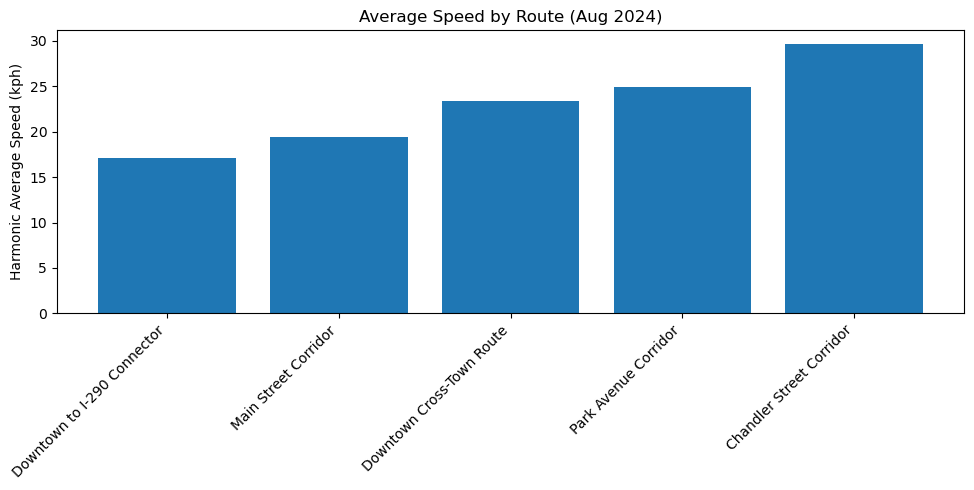

In [10]:
# This cell plots average harmonic speed by route.

plot_df = route_overall.sort_values("avg_speed_kph", ascending=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["route_name"], plot_df["avg_speed_kph"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Harmonic Average Speed (kph)")
plt.title("Average Speed by Route (Aug 2024)")
plt.tight_layout()
plt.show()

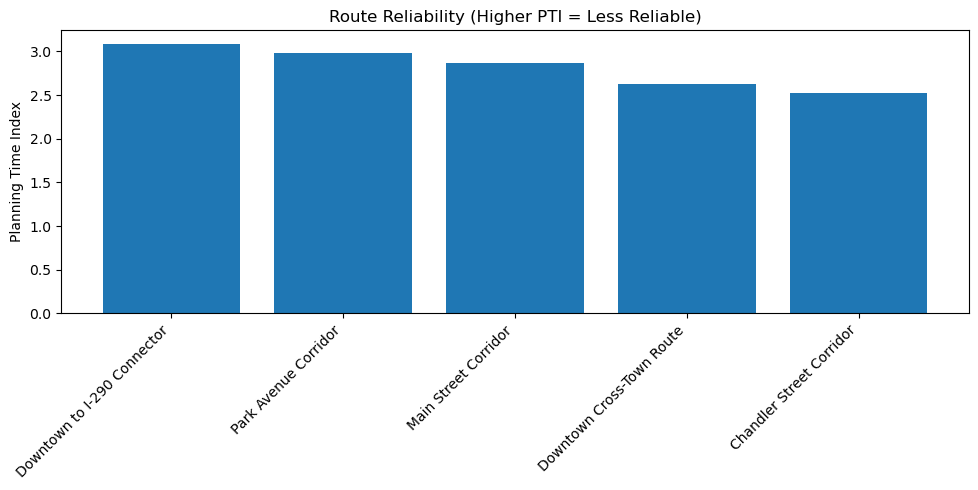

In [11]:
# This cell plots route reliability using Planning Time Index.

plot_df = route_overall.sort_values("avg_planning_time_index", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["route_name"], plot_df["avg_planning_time_index"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Planning Time Index")
plt.title("Route Reliability (Higher PTI = Less Reliable)")
plt.tight_layout()
plt.show()

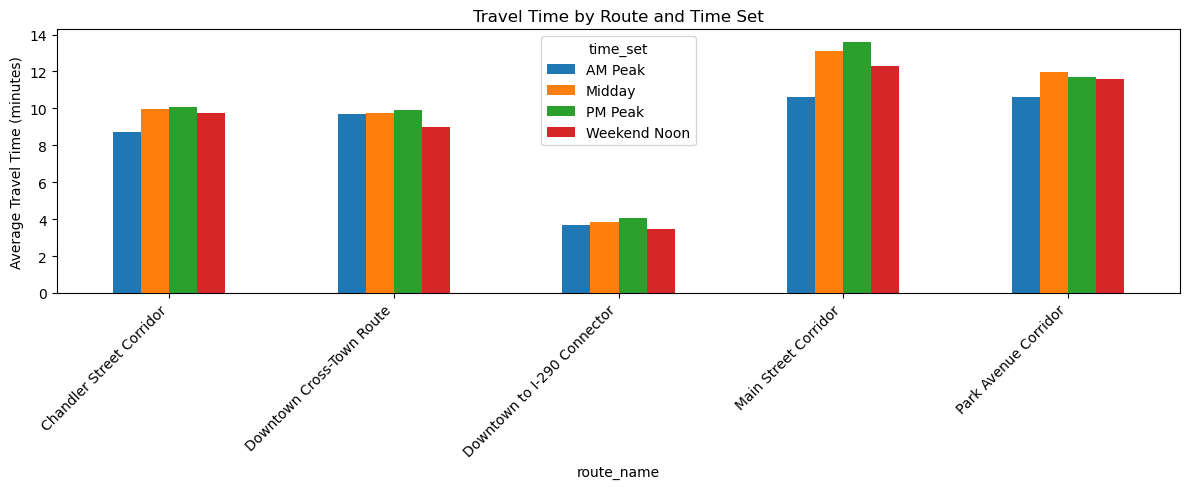

In [12]:
# This cell compares route travel time across the four time sets.

route_time = summary.pivot(index="route_name", columns="time_set", values="avg_travel_time_min")
route_time = route_time[["AM Peak", "Midday", "PM Peak", "Weekend Noon"]]

route_time.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Average Travel Time (minutes)")
plt.title("Travel Time by Route and Time Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

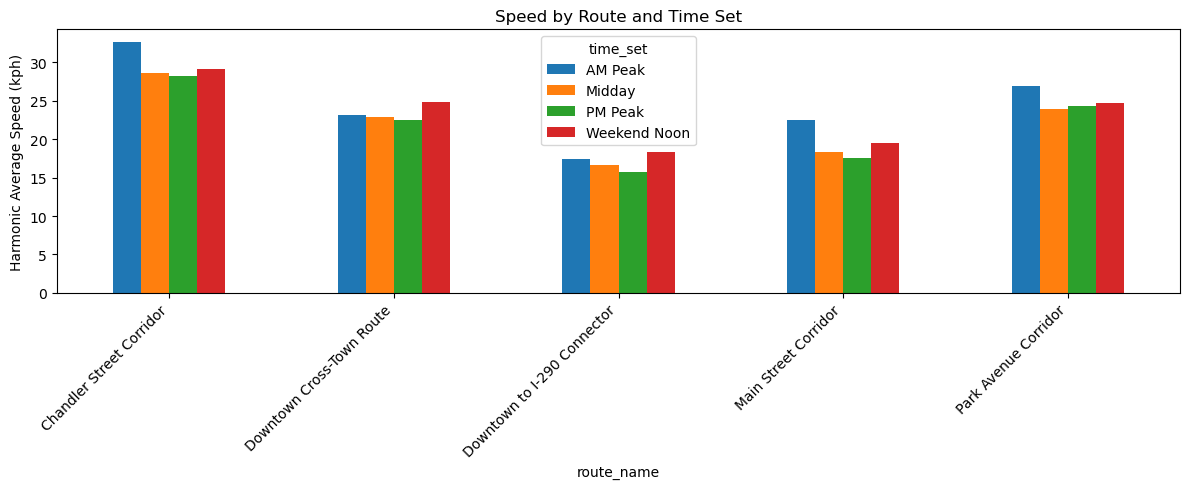

In [13]:
# This cell compares route speed across the four time sets.

route_speed = summary.pivot(index="route_name", columns="time_set", values="harmonic_avg_speed_kph")
route_speed = route_speed[["AM Peak", "Midday", "PM Peak", "Weekend Noon"]]

route_speed.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Harmonic Average Speed (kph)")
plt.title("Speed by Route and Time Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# This cell creates a route ID to route name mapping for the segment-level sheets.

route_map = (
    summary[["route_id", "route_name"]]
    .drop_duplicates()
    .sort_values("route_id")
    .reset_index(drop=True)
)

route_map

,route_id,route_name
0,1,Main Street Corridor
1,2,Park Avenue Corridor
2,3,Chandler Street Corridor
3,4,Downtown to I-290 Connector
4,5,Downtown Cross-Town Route


In [15]:
# This cell defines a reusable function for reading segment-level metric sheets and reshaping them into long format.

def read_segment_metric_sheet(workbook_path, route_id, suffix, value_prefix, header_row=4):
    sheet_name = f"Route{route_id}-{suffix}"

    df = pd.read_excel(
        workbook_path,
        sheet_name=sheet_name,
        engine="openpyxl",
        header=header_row
    ).dropna(how="all").copy()

    df.columns = [clean_col(c) for c in df.columns]

    base_cols = [
        "Segment ID",
        "New Segment ID",
        "Distance along route (m)",
        "Speed Limit(kph)",
        "Street Name"
    ]

    value_cols = [c for c in df.columns if c.startswith(value_prefix)]

    keep_cols = [c for c in base_cols if c in df.columns] + value_cols
    df = df[keep_cols].copy()

    df = df.rename(columns={
        "Segment ID": "segment_id",
        "New Segment ID": "new_segment_id",
        "Distance along route (m)": "distance_m",
        "Speed Limit(kph)": "speed_limit_kph",
        "Street Name": "street_name"
    })

    id_vars = [c for c in ["segment_id", "new_segment_id", "distance_m", "speed_limit_kph", "street_name"] if c in df.columns]

    long_df = df.melt(
        id_vars=id_vars,
        value_vars=value_cols,
        var_name="metric_time_set",
        value_name="value"
    )

    long_df["route_id"] = route_id
    long_df["time_set_raw"] = long_df["metric_time_set"].str.replace(value_prefix, "", regex=False).str.strip()
    long_df["time_set"] = long_df["time_set_raw"].apply(normalize_time_set_label)

    return long_df

In [16]:
# This cell reads all harmonic-speed segment sheets and combines them into one long table.

speed_long_list = []

for rid in route_map["route_id"]:
    tmp = read_segment_metric_sheet(
        workbook_path=workbook_path,
        route_id=rid,
        suffix="Speeds(harmonic avg)",
        value_prefix="Speed(kph)"
    )
    speed_long_list.append(tmp)

speed_long = pd.concat(speed_long_list, ignore_index=True)
speed_long = speed_long.merge(route_map, on="route_id", how="left")
speed_long = speed_long.rename(columns={"value": "speed_kph"})

print("speed_long shape:", speed_long.shape)
speed_long.head()

speed_long shape: (1816, 11)


,segment_id,new_segment_id,distance_m,speed_limit_kph,street_name,metric_time_set,speed_kph,route_id,time_set_raw,time_set,route_name
0,258400000506020,0000554d-4100-0400-0000-0000000c3eaa,11.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,28.9,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
1,258400000265907,0000554d-4100-0400-0000-0000000c3c37,90.69,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,31.5,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
2,258400000553424,0000554d-4100-0400-0000-0000000c3c38,158.25,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,29.3,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
3,258400000225544,0000554d-4100-0400-0000-0000000c58a8,226.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,22.0,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
4,-258400000582128,-0000554d-4100-0400-0000-00000014072f,236.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,17.9,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor


In [17]:
# This cell reads all sample-size segment sheets and combines them into one long table.

sample_long_list = []

for rid in route_map["route_id"]:
    tmp = read_segment_metric_sheet(
        workbook_path=workbook_path,
        route_id=rid,
        suffix="Sample size",
        value_prefix="Sample size"
    )
    sample_long_list.append(tmp)

sample_long = pd.concat(sample_long_list, ignore_index=True)
sample_long = sample_long.merge(route_map, on="route_id", how="left")
sample_long = sample_long.rename(columns={"value": "sample_size"})

print("sample_long shape:", sample_long.shape)
sample_long.head()

sample_long shape: (1816, 11)


,segment_id,new_segment_id,distance_m,speed_limit_kph,street_name,metric_time_set,sample_size,route_id,time_set_raw,time_set,route_name
0,258400000506020,0000554d-4100-0400-0000-0000000c3eaa,11.02,56,Main St,Sample size AM_Peak: 7:00-9:00,1676,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
1,258400000265907,0000554d-4100-0400-0000-0000000c3c37,90.69,56,Main St,Sample size AM_Peak: 7:00-9:00,1900,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
2,258400000553424,0000554d-4100-0400-0000-0000000c3c38,158.25,56,Main St,Sample size AM_Peak: 7:00-9:00,1868,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
3,258400000225544,0000554d-4100-0400-0000-0000000c58a8,226.02,56,Main St,Sample size AM_Peak: 7:00-9:00,1737,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor
4,-258400000582128,-0000554d-4100-0400-0000-00000014072f,236.02,56,Main St,Sample size AM_Peak: 7:00-9:00,1744,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor


In [18]:
# This cell reads all travel-time-ratio segment sheets and fixes the PM/Midday/Weekend time-set parsing.

ratio_long_list = []

for rid in route_map["route_id"]:
    tmp = read_segment_metric_sheet(
        workbook_path=workbook_path,
        route_id=rid,
        suffix="TravelTimeRatio",
        value_prefix="Ratio"
    )
    ratio_long_list.append(tmp)

ratio_long = pd.concat(ratio_long_list, ignore_index=True)
ratio_long = ratio_long.merge(route_map, on="route_id", how="left")
ratio_long = ratio_long.rename(columns={"value": "travel_time_ratio_vs_am"})

print("ratio_long shape:", ratio_long.shape)
print("\nParsed time sets in ratio_long:")
print(ratio_long["time_set"].value_counts(dropna=False))

ratio_long.head()

ratio_long shape: (1362, 11)

Parsed time sets in ratio_long:
time_set
Midday          454
PM Peak         454
Weekend Noon    454
Name: count, dtype: int64


,segment_id,new_segment_id,distance_m,speed_limit_kph,street_name,metric_time_set,travel_time_ratio_vs_am,route_id,time_set_raw,time_set,route_name
0,258400000506020,0000554d-4100-0400-0000-0000000c3eaa,11.02,56,Main St,Ratio Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,1.14,1,Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,Midday,Main Street Corridor
1,258400000265907,0000554d-4100-0400-0000-0000000c3c37,90.69,56,Main St,Ratio Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,1.10,1,Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,Midday,Main Street Corridor
2,258400000553424,0000554d-4100-0400-0000-0000000c3c38,158.25,56,Main St,Ratio Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,1.06,1,Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,Midday,Main Street Corridor
3,258400000225544,0000554d-4100-0400-0000-0000000c58a8,226.02,56,Main St,Ratio Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,1.07,1,Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,Midday,Main Street Corridor
4,-258400000582128,-0000554d-4100-0400-0000-00000014072f,236.02,56,Main St,Ratio Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,1.20,1,Midday: 11:00-13:00 / AM_Peak: 7:00-9:00,Midday,Main Street Corridor


In [19]:
# This cell merges speed, sample size, and ratio into one segment-level master table and saves it.

segment_df = speed_long.merge(
    sample_long[["route_id", "segment_id", "time_set", "sample_size"]],
    on=["route_id", "segment_id", "time_set"],
    how="left"
)

segment_df = segment_df.merge(
    ratio_long[["route_id", "segment_id", "time_set", "travel_time_ratio_vs_am"]],
    on=["route_id", "segment_id", "time_set"],
    how="left"
)

segment_df["route_name"] = segment_df["route_name"].apply(normalize_route_name)

segment_path = PROCESSED_DIR / "segment_metrics_long_clean.csv"
segment_df.to_csv(segment_path, index=False)

print("segment_df shape:", segment_df.shape)
print("Saved:", segment_path)

segment_df.head()

segment_df shape: (1816, 13)
Saved: D:\JupyterProjects\tomtom_move\data\processed\segment_metrics_long_clean.csv


,segment_id,new_segment_id,distance_m,speed_limit_kph,street_name,metric_time_set,speed_kph,route_id,time_set_raw,time_set,route_name,sample_size,travel_time_ratio_vs_am
0,258400000506020,0000554d-4100-0400-0000-0000000c3eaa,11.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,28.9,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor,1676,NaN
1,258400000265907,0000554d-4100-0400-0000-0000000c3c37,90.69,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,31.5,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor,1900,NaN
2,258400000553424,0000554d-4100-0400-0000-0000000c3c38,158.25,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,29.3,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor,1868,NaN
3,258400000225544,0000554d-4100-0400-0000-0000000c58a8,226.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,22.0,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor,1737,NaN
4,-258400000582128,-0000554d-4100-0400-0000-00000014072f,236.02,56,Main St,Speed(kph) AM_Peak: 7:00-9:00,17.9,1,AM_Peak: 7:00-9:00,AM Peak,Main Street Corridor,1744,NaN


In [20]:
# This cell checks how many unique street names each route has, which helps explain why bars can overlap on segment plots.

pm_segments = segment_df[segment_df["time_set"] == "PM Peak"].copy()

for route in pm_segments["route_name"].dropna().unique():
    tmp = pm_segments[pm_segments["route_name"] == route].copy()
    print(route)
    print("rows:", len(tmp))
    print("unique street names:", tmp["street_name"].nunique(dropna=True))
    print("first few street names:", tmp["street_name"].dropna().unique()[:10])
    print("-" * 50)

Main Street Corridor
rows: 96
unique street names: 1
first few street names: ['Main St']
--------------------------------------------------
Park Avenue Corridor
rows: 134
unique street names: 1
first few street names: ['Park Ave']
--------------------------------------------------
Chandler Street Corridor
rows: 93
unique street names: 1
first few street names: ['Chandler St']
--------------------------------------------------
Downtown to I-290 Connector
rows: 39
unique street names: 3
first few street names: ['Main St' 'Belmont St' 'Lincoln St']
--------------------------------------------------
Downtown Cross-Town Route
rows: 92
unique street names: 3
first few street names: ['Pleasant St' 'Highland St' 'Belmont St']
--------------------------------------------------


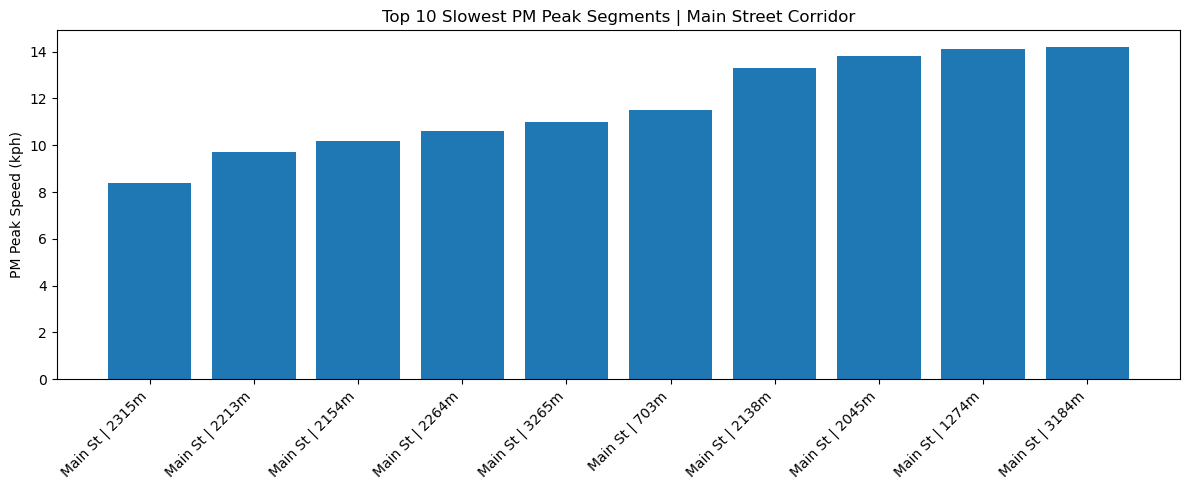

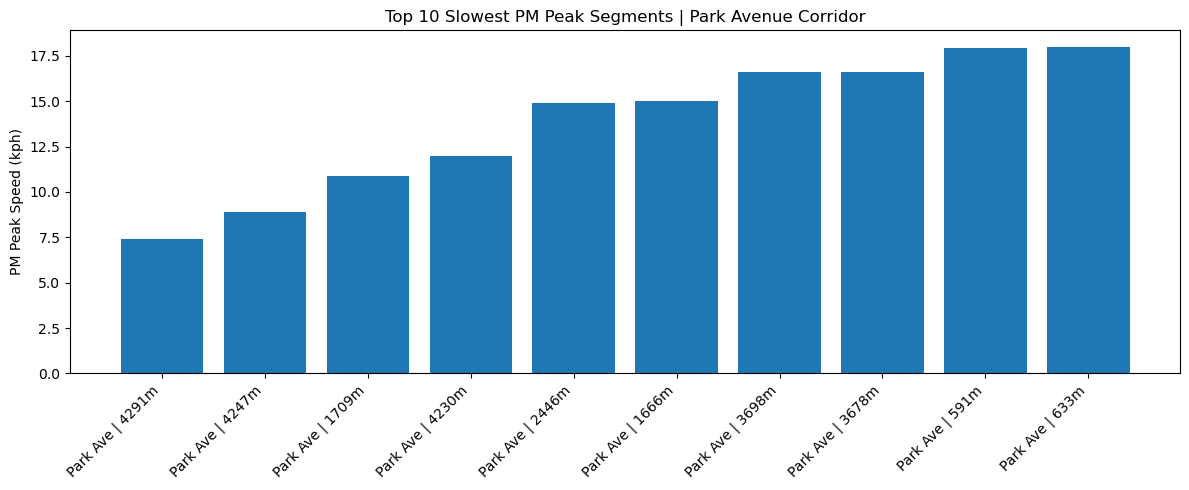

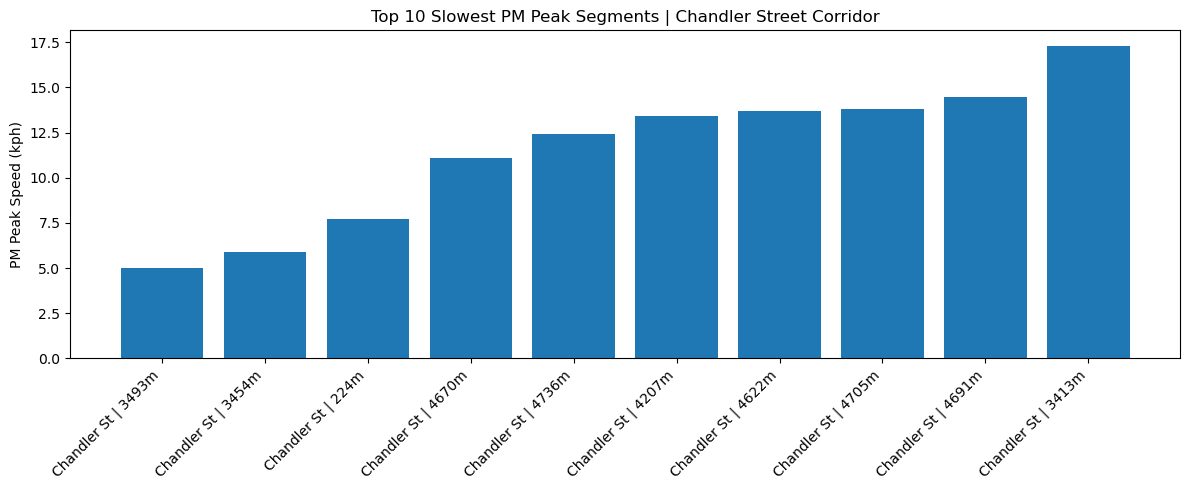

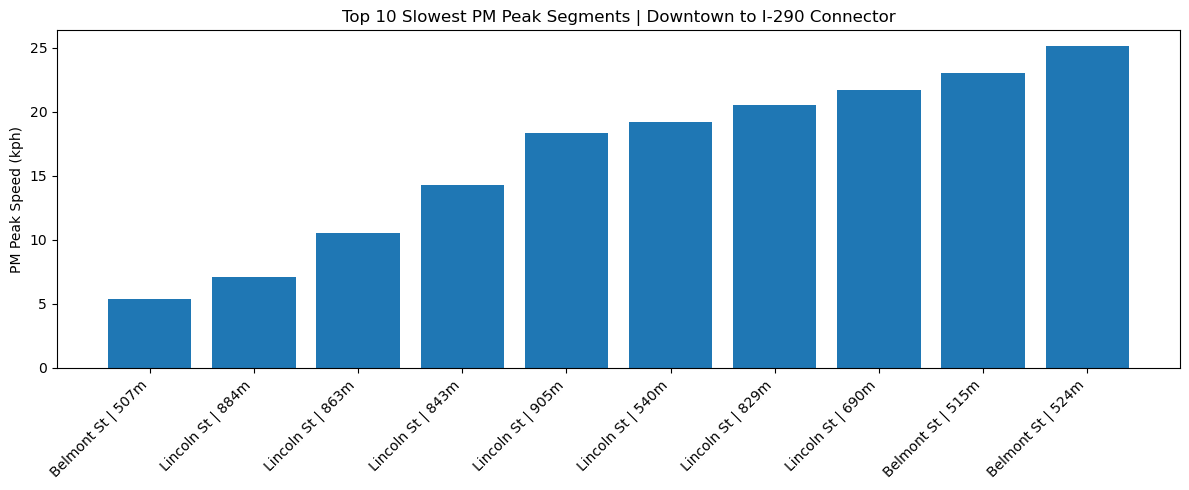

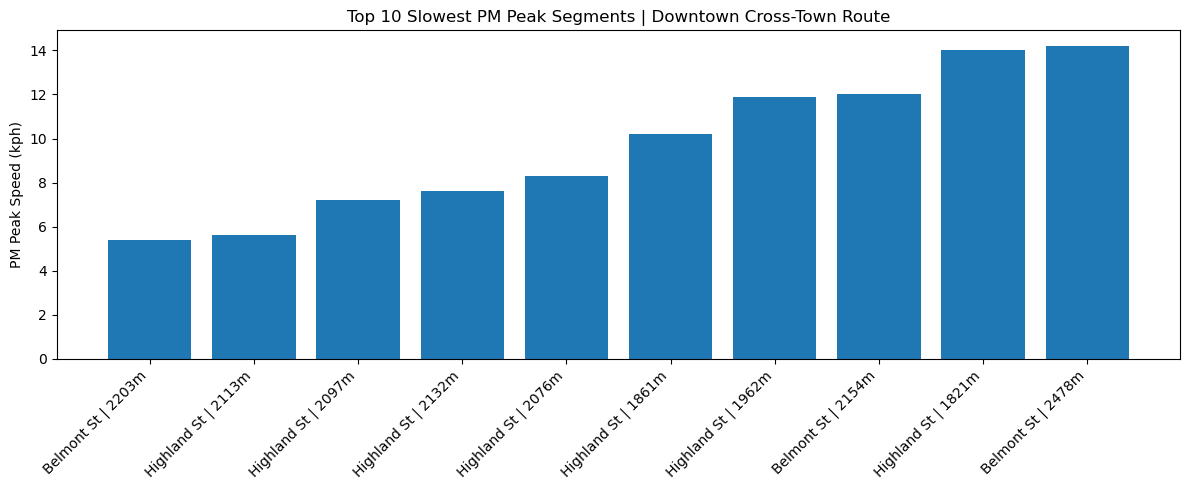

In [21]:
# This cell plots the top 10 slowest PM Peak segments for each route using unique labels to avoid bar overlap.

for route in pm_segments["route_name"].dropna().unique():
    tmp = pm_segments[pm_segments["route_name"] == route].copy()

    threshold = tmp["sample_size"].median()
    tmp = tmp[tmp["sample_size"] >= threshold].copy()

    tmp = tmp.dropna(subset=["speed_kph"])

    if tmp.empty:
        print(f"{route}: no valid PM Peak speed data after filtering")
        continue

    tmp = tmp.sort_values("speed_kph", ascending=True).head(10).copy()
    tmp["label"] = make_segment_label(tmp)

    plt.figure(figsize=(12, 5))
    plt.bar(tmp["label"], tmp["speed_kph"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("PM Peak Speed (kph)")
    plt.title(f"Top 10 Slowest PM Peak Segments | {route}")
    plt.tight_layout()
    plt.show()

ratio_pm shape: (454, 11)


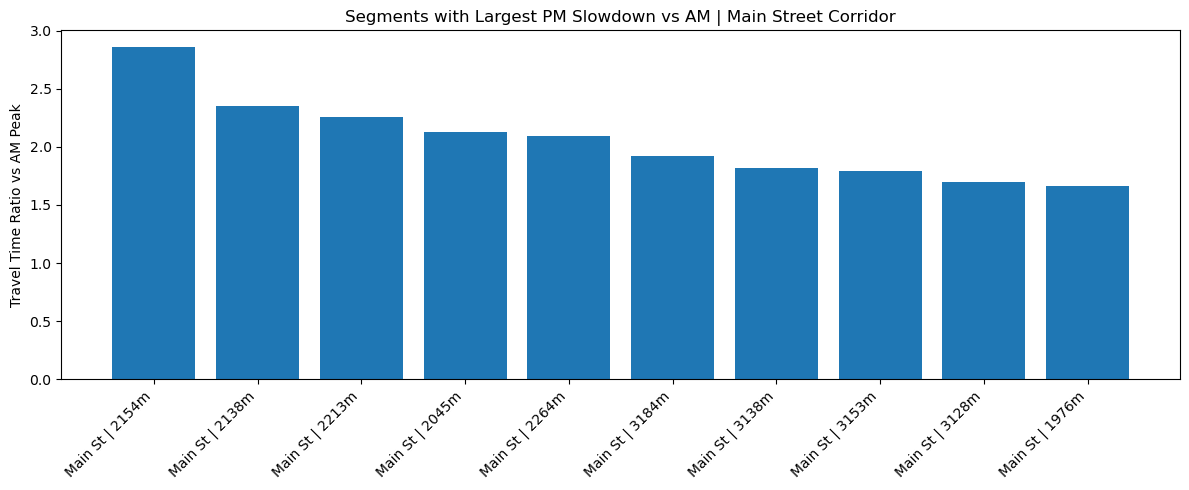

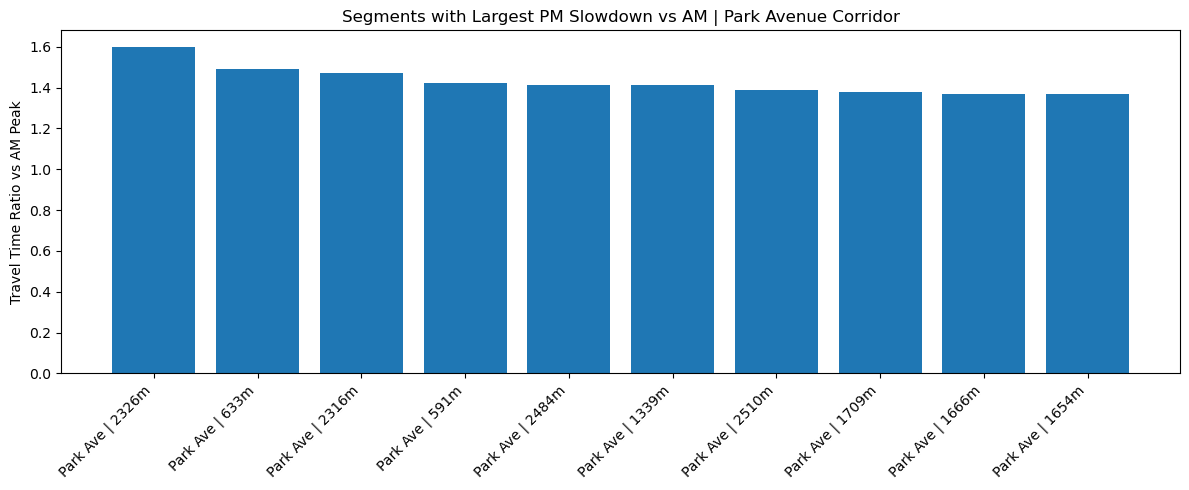

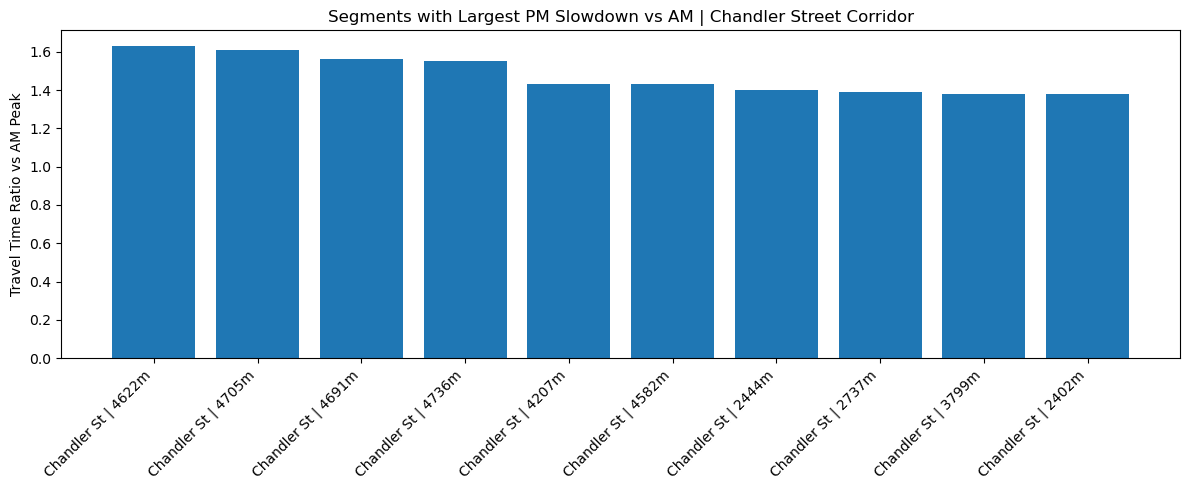

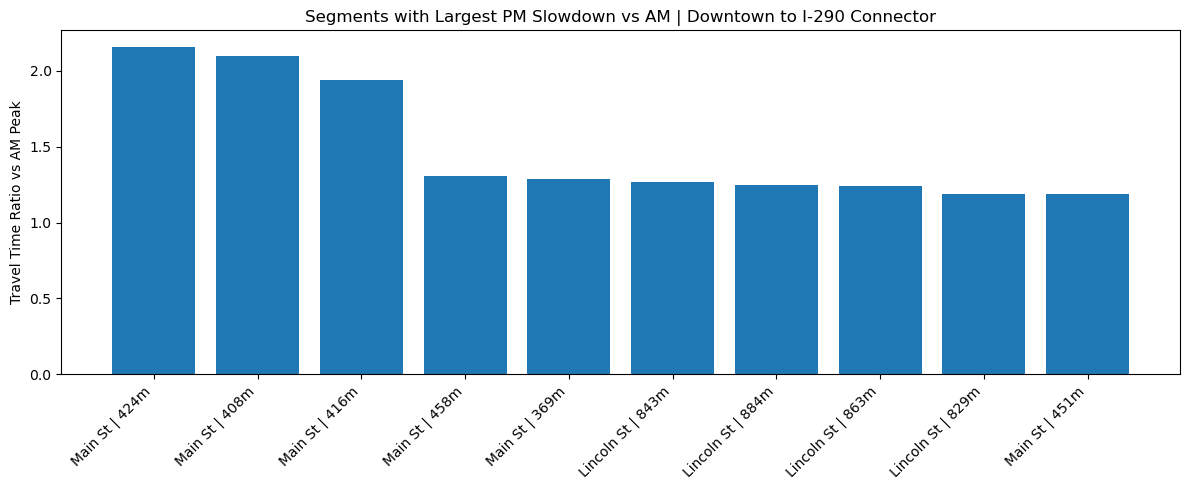

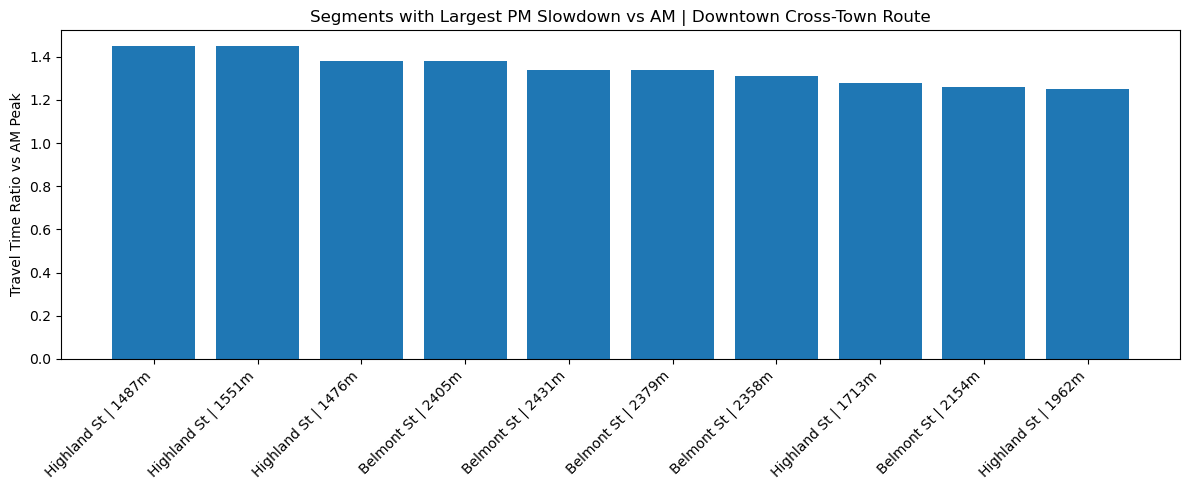

In [22]:
# This cell plots the segments with the largest PM slowdown relative to AM Peak, again using unique labels.

ratio_pm = ratio_long[ratio_long["time_set"] == "PM Peak"].copy()

print("ratio_pm shape:", ratio_pm.shape)

for route in ratio_pm["route_name"].dropna().unique():
    tmp = ratio_pm[ratio_pm["route_name"] == route].copy()
    tmp = tmp.dropna(subset=["travel_time_ratio_vs_am"])

    if tmp.empty:
        print(f"{route}: no valid PM Peak ratio data")
        continue

    tmp = tmp.sort_values("travel_time_ratio_vs_am", ascending=False).head(10).copy()
    tmp["label"] = make_segment_label(tmp)

    plt.figure(figsize=(12, 5))
    plt.bar(tmp["label"], tmp["travel_time_ratio_vs_am"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Travel Time Ratio vs AM Peak")
    plt.title(f"Segments with Largest PM Slowdown vs AM | {route}")
    plt.tight_layout()
    plt.show()

In [23]:
# This cell creates a final presentation-ready summary table and saves it.

final_summary = summary[[
    "route_name", "time_set",
    "avg_travel_time_min",
    "median_travel_time_min",
    "harmonic_avg_speed_kph",
    "sample_size_avg",
    "avg_travel_time_ratio",
    "planning_time_index"
]].copy()

final_summary = final_summary.sort_values(
    ["route_name", "time_set"]
).reset_index(drop=True)

final_summary_path = PROCESSED_DIR / "final_route_time_set_summary.csv"
final_summary.to_csv(final_summary_path, index=False)

print("Saved:", final_summary_path)
final_summary

Saved: D:\JupyterProjects\tomtom_move\data\processed\final_route_time_set_summary.csv


,route_name,time_set,avg_travel_time_min,median_travel_time_min,harmonic_avg_speed_kph,sample_size_avg,avg_travel_time_ratio,planning_time_index
0,Chandler Street Corridor,AM Peak,8.700000,6.316667,32.64,5466.17,1.00,2.22
1,Chandler Street Corridor,Midday,9.950000,6.933333,28.56,4952.67,1.14,2.61
2,Chandler Street Corridor,PM Peak,10.066667,6.966667,28.23,7832.43,1.16,2.71
3,Chandler Street Corridor,Weekend Noon,9.750000,6.833333,29.16,2346.85,1.12,2.58
4,Downtown Cross-Town Route,AM Peak,9.666667,6.100000,23.13,7325.32,1.00,2.72
5,Downtown Cross-Town Route,Midday,9.750000,6.450000,22.90,5816.97,1.01,2.65
6,Downtown Cross-Town Route,PM Peak,9.933333,6.500000,22.47,10868.41,1.03,2.78
7,Downtown Cross-Town Route,Weekend Noon,9.000000,6.066667,24.83,2934.51,0.93,2.37
8,Downtown to I-290 Connector,AM Peak,3.666667,2.016667,17.45,5310.59,1.00,2.87
9,Downtown to I-290 Connector,Midday,3.833333,2.150000,16.64,4963.10,1.05,3.16


In [24]:
# This cell creates a compact route-level ranking table for quick interpretation.

route_ranking = route_overall.copy()
route_ranking["travel_time_rank"] = route_ranking["avg_travel_time_min"].rank(method="min", ascending=False)
route_ranking["speed_rank"] = route_ranking["avg_speed_kph"].rank(method="min", ascending=True)
route_ranking["reliability_rank"] = route_ranking["avg_planning_time_index"].rank(method="min", ascending=False)

route_ranking = route_ranking.sort_values("travel_time_rank")

route_ranking_path = PROCESSED_DIR / "route_ranking_aug2024.csv"
route_ranking.to_csv(route_ranking_path, index=False)

print("Saved:", route_ranking_path)
route_ranking

Saved: D:\JupyterProjects\tomtom_move\data\processed\route_ranking_aug2024.csv


,route_name,avg_travel_time_min,median_travel_time_min,avg_speed_kph,avg_sample_size,avg_ratio,avg_planning_time_index,travel_time_rank,speed_rank,reliability_rank
3,Main Street Corridor,12.400000,8.529167,19.4400,3220.7875,1.1675,2.8675,1.0,2.0,3.0
4,Park Avenue Corridor,11.454167,7.283333,24.9450,7575.6900,1.0800,2.9850,2.0,4.0,2.0
0,Chandler Street Corridor,9.616667,6.762500,29.6475,5149.5300,1.1050,2.5300,3.0,5.0,5.0
1,Downtown Cross-Town Route,9.587500,6.279167,23.3325,6736.3025,0.9925,2.6300,4.0,3.0,4.0
2,Downtown to I-290 Connector,3.762500,2.058333,17.0425,5188.9475,1.0275,3.0875,5.0,1.0,1.0
